In [1]:
# Install if needed
!pip install pandas numpy scikit-learn nltk

# Imports
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

import matplotlib.pyplot as plt

In [2]:
# Load your CSV file
df = pd.read_csv('Gammas.csv')

# Preview
df.head()

,timepoint,ROI,subject,BOLD signal
0,0.0,IPS,0,0.513433
1,0.0,IPS,1,-0.414368
2,0.0,IPS,2,0.214695
3,0.0,IPS,3,0.814809
4,0.0,IPS,4,-0.894992


In [4]:
df.head()

,timepoint,ROI,subject,BOLD signal
0,0.0,IPS,0,0.513433
1,0.0,IPS,1,-0.414368
2,0.0,IPS,2,0.214695
3,0.0,IPS,3,0.814809
4,0.0,IPS,4,-0.894992


In [5]:
col = df.columns[0]  # just grab the first column
df['clean_text'] = df[col].apply(preprocess)

In [7]:
df = df[df['clean_text'].notna()]
df = df[df['clean_text'].str.strip() != '']

In [9]:
print(df['clean_text'].head(10))
print(df['clean_text'].isna().sum())
print((df['clean_text'].str.strip() == '').sum())

Series([], Name: clean_text, dtype: str)
0
0


In [11]:


df.head()

,timepoint,ROI,subject,BOLD signal,clean_text


In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# Example input (replace with your actual text data)
documents = [
    "I love machine learning and data science",
    "AI and deep learning are the future",
    "Football and sports are fun",
    "I enjoy watching basketball and football",
    "Data science includes statistics and programming"
]

# Number of clusters
k = 2

# Step 1: Vectorize the text (FIT happens here)
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(documents)

# Step 2: Fit KMeans
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans.fit(X)

# Step 3: Get feature names (NOW it's fitted, so no error)
terms = vectorizer.get_feature_names_out()

# Step 4: Print top words per cluster
for i in range(k):
    center = kmeans.cluster_centers_[i]
    
    # Get top 10 words (highest weights first)
    top_indices = center.argsort()[-10:][::-1]
    top_words = [terms[ind] for ind in top_indices]
    
    print(f"\nCluster {i} top words:")
    print(top_words)


Cluster 0 top words:
['learning', 'data', 'science', 'ai', 'future', 'deep', 'machine', 'love', 'includes', 'statistics']

Cluster 1 top words:
['football', 'sports', 'fun', 'watching', 'basketball', 'enjoy', 'future', 'data', 'deep', 'includes']


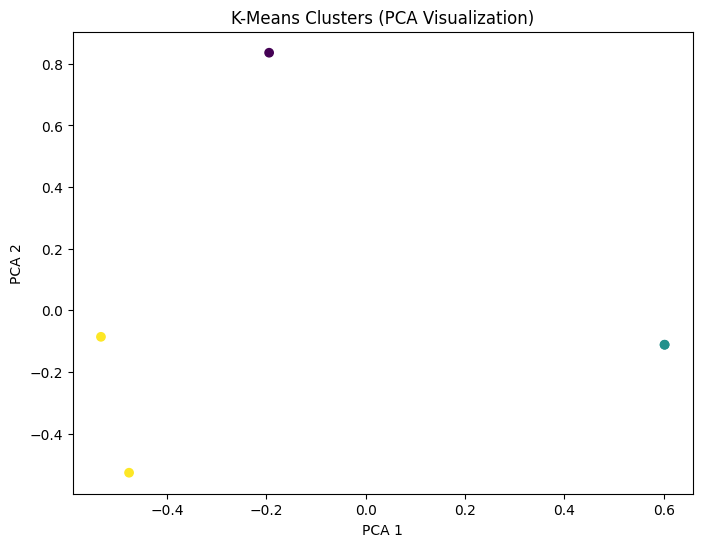

In [15]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['cluster'], cmap='viridis')

plt.title("K-Means Clusters (PCA Visualization)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [16]:
df.to_csv('Gammas_clustered.csv', index=False)